In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
from wordcloud import WordCloud, STOPWORDS
plt.style.use('seaborn-v0_8')
sns.set_style('whitegrid')
%matplotlib inline

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

pd.options.mode.chained_assignment = None

In [2]:
food_fact = pd.read_csv("/content/data.csv")

<ipython-input-2-b2a68d14faac>:1: DtypeWarning: Columns (8,9,10,11,17,18,19,20,21,22,23,24,25,26,28,29,30,35,37,38,39,48,61,62) have mixed types. Specify dtype option on import or set low_memory=False.
  food_fact = pd.read_csv("/content/data.csv")


In [3]:
#untuk menampilkan semua 163 kolom
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [4]:
data=food_fact.dropna(thresh=0.7*len(food_fact), axis=1)
print(f"Data shape sebelum {food_fact.shape}")
print(f"Data shape setelah {data.shape}")
print(f"Kita membuang {food_fact.shape[1]- data.shape[1]} kolom")

Data shape sebelum (8665, 163)
Data shape setelah (8665, 40)
Kita membuang 123 kolom


In [5]:
df=data.fillna(0, axis=1)
df.head()

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,brands,brands_tags,countries,countries_tags,countries_en,ingredients_text,serving_size,additives_n,additives,ingredients_from_palm_oil_n,ingredients_that_may_be_from_palm_oil_n,nutrition_grade_fr,states,states_tags,states_en,energy_100g,fat_100g,saturated-fat_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g,vitamin-a_100g,vitamin-c_100g,calcium_100g,iron_100g,nutrition-score-fr_100g,nutrition-score-uk_100g
0,3087,http://world-en.openfoodfacts.org/product/0000...,openfoodfacts-contributors,1474103866,2016-09-17T09:17:46Z,1474103893,2016-09-17T09:18:13Z,Farine de blé noir,Ferme t'y R'nao,ferme-t-y-r-nao,en:FR,en:france,France,0,0,0,0,0,0,0,"en:to-be-completed, en:nutrition-facts-to-be-c...","en:to-be-completed,en:nutrition-facts-to-be-co...","To be completed,Nutrition facts to be complete...",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,4530,http://world-en.openfoodfacts.org/product/0000...,usda-ndb-import,1489069957,2017-03-09T14:32:37Z,1489069957,2017-03-09T14:32:37Z,Banana Chips Sweetened (Whole),0,0,US,en:united-states,United States,"Bananas, vegetable oil (coconut oil, corn oil ...",28 g (1 ONZ),0.0,[ bananas -> en:bananas ] [ vegetable-oil -...,0.0,0.0,d,"en:to-be-completed, en:nutrition-facts-complet...","en:to-be-completed,en:nutrition-facts-complete...","To be completed,Nutrition facts completed,Ingr...",2243.0,28.57,28.57,0.0,0.018,64.29,14.29,3.6,3.57,0.0,0.0,0.0,0.0214,0.0,0.00129,14.0,14.0
2,4559,http://world-en.openfoodfacts.org/product/0000...,usda-ndb-import,1489069957,2017-03-09T14:32:37Z,1489069957,2017-03-09T14:32:37Z,Peanuts,Torn & Glasser,torn-glasser,US,en:united-states,United States,"Peanuts, wheat flour, sugar, rice flour, tapio...",28 g (0.25 cup),0.0,[ peanuts -> en:peanuts ] [ wheat-flour -> ...,0.0,0.0,b,"en:to-be-completed, en:nutrition-facts-complet...","en:to-be-completed,en:nutrition-facts-complete...","To be completed,Nutrition facts completed,Ingr...",1941.0,17.86,0.0,0.0,0.0,60.71,17.86,7.1,17.86,0.635,0.25,0.0,0.0,0.071,0.00129,0.0,0.0
3,16087,http://world-en.openfoodfacts.org/product/0000...,usda-ndb-import,1489055731,2017-03-09T10:35:31Z,1489055731,2017-03-09T10:35:31Z,Organic Salted Nut Mix,Grizzlies,grizzlies,US,en:united-states,United States,"Organic hazelnuts, organic cashews, organic wa...",28 g (0.25 cup),0.0,[ organic-hazelnuts -> en:organic-hazelnuts ...,0.0,0.0,d,"en:to-be-completed, en:nutrition-facts-complet...","en:to-be-completed,en:nutrition-facts-complete...","To be completed,Nutrition facts completed,Ingr...",2540.0,57.14,5.36,0,0,17.86,3.57,7.1,17.86,1.22428,0.482,0,0,0.143,0.00514,12.0,12.0
4,16094,http://world-en.openfoodfacts.org/product/0000...,usda-ndb-import,1489055653,2017-03-09T10:34:13Z,1489055653,2017-03-09T10:34:13Z,Organic Polenta,Bob's Red Mill,bob-s-red-mill,US,en:united-states,United States,Organic polenta,35 g (0.25 cup),0.0,[ organic-polenta -> en:organic-polenta ] [...,0.0,0.0,0,"en:to-be-completed, en:nutrition-facts-complet...","en:to-be-completed,en:nutrition-facts-complete...","To be completed,Nutrition facts completed,Ingr...",1552.0,1.43,0,0,0,77.14,0,5.7,8.57,0,0,0,0,0,0,0,0


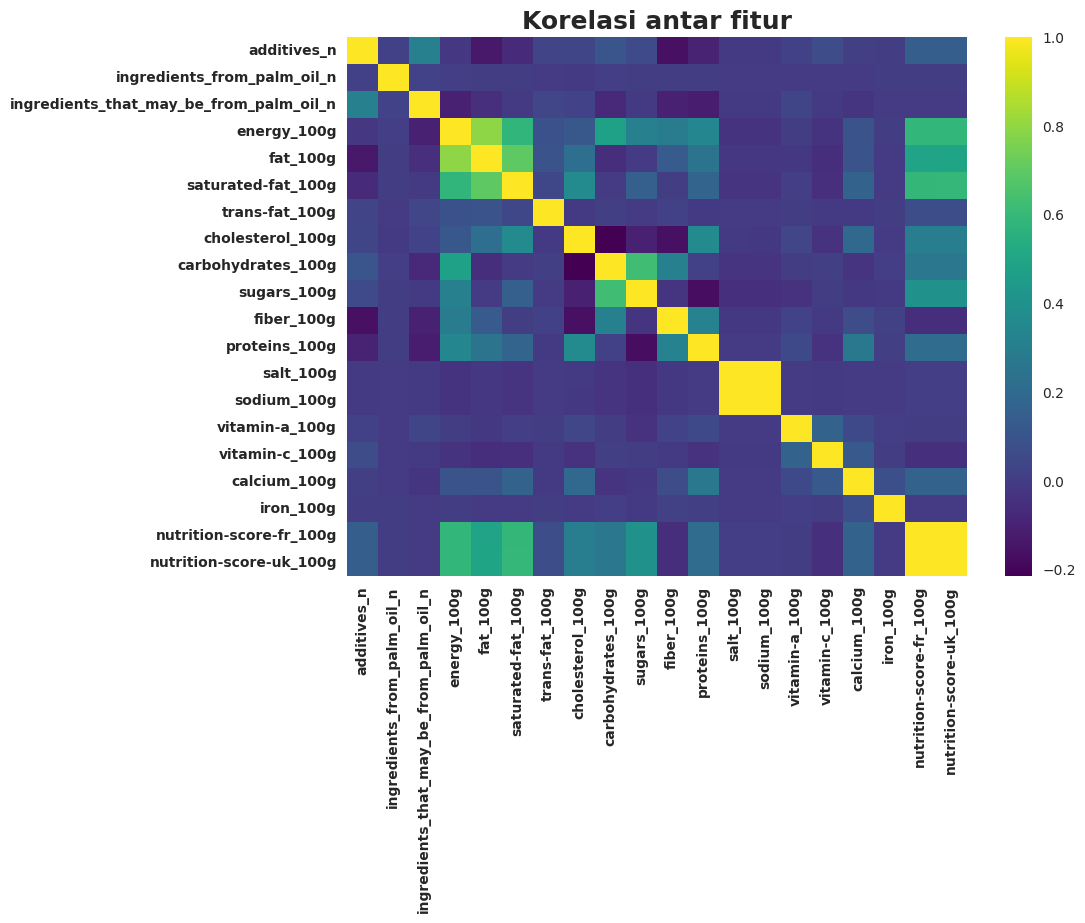

In [6]:
kolom_drop = ['code','url','creator', 'created_t', 'last_modified_t',	'last_modified_datetime',
              'created_datetime','product_name','brands', 'brands_tags', 'serving_size',
              'countries', 'countries_tags','countries_en','ingredients_text',
              'additives','nutrition_grade_fr','states','states_tags','states_en']
df_clean = df.drop(kolom_drop, axis=1)

df_corr=df_clean.corr()
f,ax=plt.subplots(figsize=(10,7))
sns.heatmap(df_corr, cmap='viridis')
plt.title("Korelasi antar fitur",
          weight='bold',
          fontsize=18)
plt.xticks(weight='bold')
plt.yticks(weight='bold')

plt.show()

In [7]:
databaru = df[['product_name','energy_100g', 'fat_100g',
       'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g',
       'proteins_100g']]
print(f"kita mempunyai {databaru.shape[0]} produk di supermarkets and {databaru.shape[1]} features")

kita mempunyai 8665 produk di supermarkets and 7 features


In [8]:
keto= databaru[(databaru['energy_100g']<2000)&(databaru['carbohydrates_100g']<40)&(databaru['fat_100g']<165)&(databaru['proteins_100g']<75)]
print(f'Kita memiliki {keto.shape[0]} keto produk di supermarkets')

Kita memiliki 4755 keto produk di supermarkets


In [9]:
#fitur seleksi
ketoc=keto[['energy_100g','fat_100g', 'saturated-fat_100g','carbohydrates_100g', 'sugars_100g', 'proteins_100g']]

In [10]:
from scipy.stats import skew

numeric_feats = ketoc.dtypes[ketoc.dtypes != "object"].index

skewed_feats = ketoc[numeric_feats].apply(lambda x: skew(x.dropna()))
skewed_feats = skewed_feats[skewed_feats > 0.75]
skewed_feats = skewed_feats.index

ketoc[skewed_feats] = np.log1p(ketoc[skewed_feats])

/usr/local/lib/python3.10/dist-packages/scipy/stats/_stats_py.py:1177: RuntimeWarning: Mean of empty slice.
  mean = a.mean(axis, keepdims=True)
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.10/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [11]:
from sklearn.preprocessing import RobustScaler

scaler=RobustScaler()
scaler.fit(ketoc)

RobustScaler()

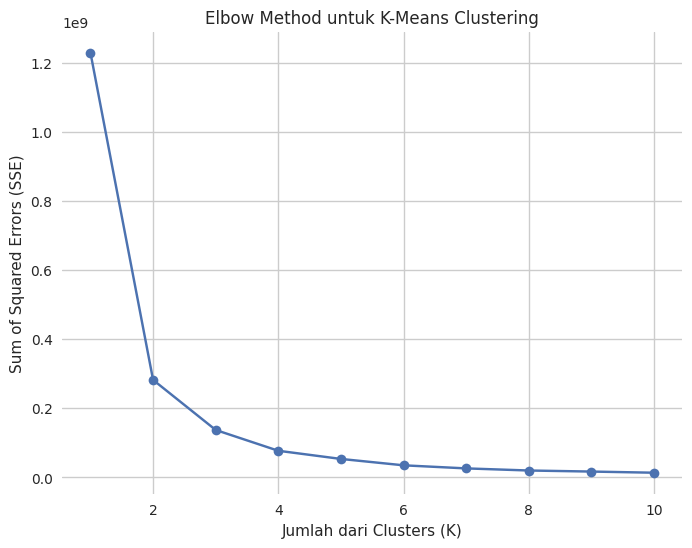

In [12]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


K_range = range(1, 11)
SSE = []
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(ketoc)
    SSE.append(kmeans.inertia_)


plt.figure(figsize=(8, 6))
plt.plot(K_range, SSE, marker='o', linestyle='-')
plt.xlabel('Jumlah dari Clusters (K)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Elbow Method untuk K-Means Clustering')
plt.grid(True)
plt.show()

In [13]:
from sklearn.cluster import KMeans
import numpy as np

kmeans = KMeans(n_clusters=3
                       ,init = 'k-means++'
                       , n_init = 10
                       , tol = 0.0001
                       , random_state = 1).fit(ketoc)
labels2 = kmeans.labels_

centers=kmeans.cluster_centers_

In [14]:
col_dic={0:'red',
1:'blue',
2:'green',
3:'yellow'
}

pred1 = kmeans.fit_predict(ketoc)
color_km = [col_dic[x] for x in pred1]
def plot_km_cluster(keto, color):
    fig, ax = plt.subplots(2, 2, figsize=(12,11))
    x_cols = ['carbohydrates_100g', 'fat_100g', 'sugars_100g', 'proteins_100g']
    y_cols = ['energy_100g', 'proteins_100g', 'energy_100g', 'carbohydrates_100g']
    for x_col,y_col,i,j in zip(x_cols,y_cols,[0,0,1,1],[0,1,0,1]):
        for x,y,c in zip(ketoc[x_col], ketoc[y_col], color_km):
            ax[i,j].scatter(x,y, color = c)
        ax[i,j].set_title('Scatter plot of ' + y_col + ' vs. ' + x_col)
        ax[i,j].set_xlabel(x_col)
        ax[i,j].set_ylabel(y_col)
    plt.show()

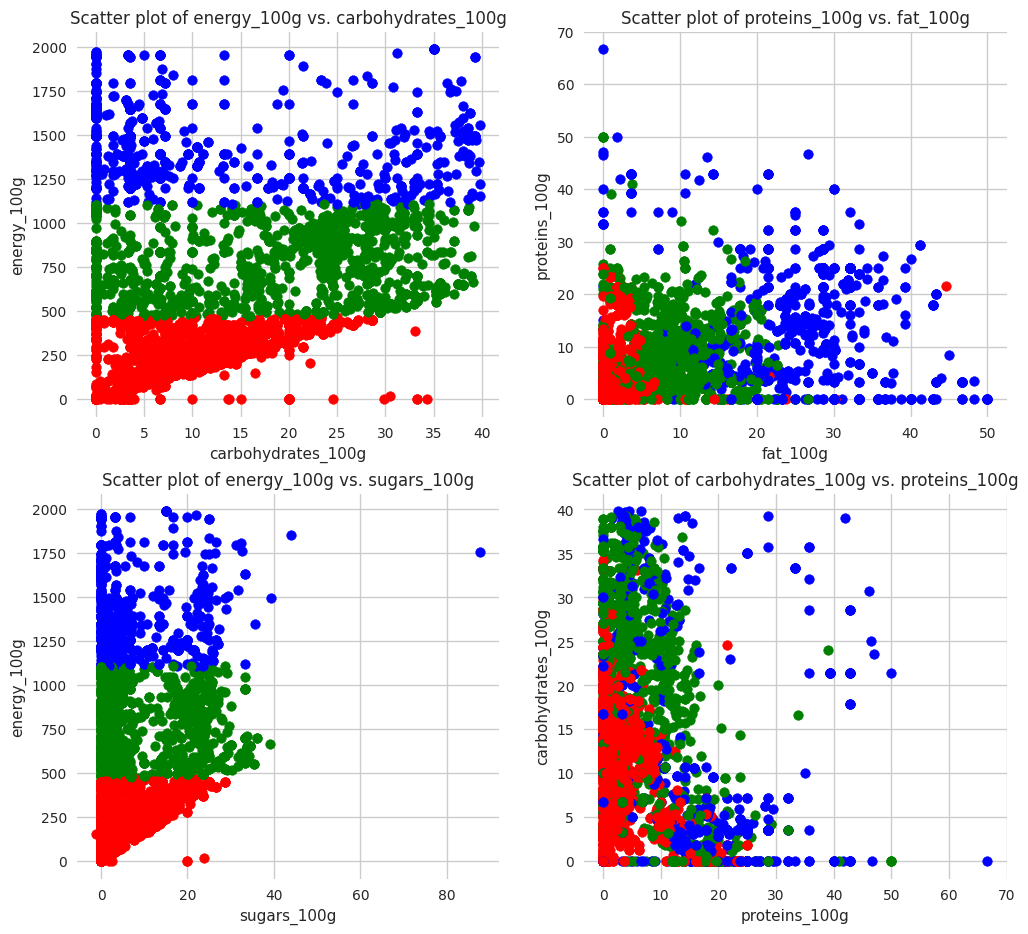

In [15]:
plot_km_cluster(keto, color_km)

In [16]:
keto['km_cluster']= kmeans.fit_predict(ketoc)

In [17]:
cluster0=keto[keto['km_cluster']==0]
cluster1=keto[keto['km_cluster']==1]
cluster2=keto[keto['km_cluster']==2]

cluster0['product_name']=cluster0['product_name'].astype(str)
cluster1['product_name']=cluster1['product_name'].astype(str)
cluster2['product_name']=cluster2['product_name'].astype(str)

wordcloud4 = WordCloud(width=400, height=300, background_color='white').generate(' '.join(cluster0['product_name']))
WordCloud.generate_from_frequencies

wordcloud5 = WordCloud(width=400, height=300, background_color='white').generate(' '.join(cluster1['product_name']))
WordCloud.generate_from_frequencies

wordcloud6 = WordCloud(width=400, height=300, background_color='white').generate(' '.join(cluster2['product_name']))
WordCloud.generate_from_frequencies

<function wordcloud.wordcloud.WordCloud.generate_from_frequencies(self, frequencies, max_font_size=None)>

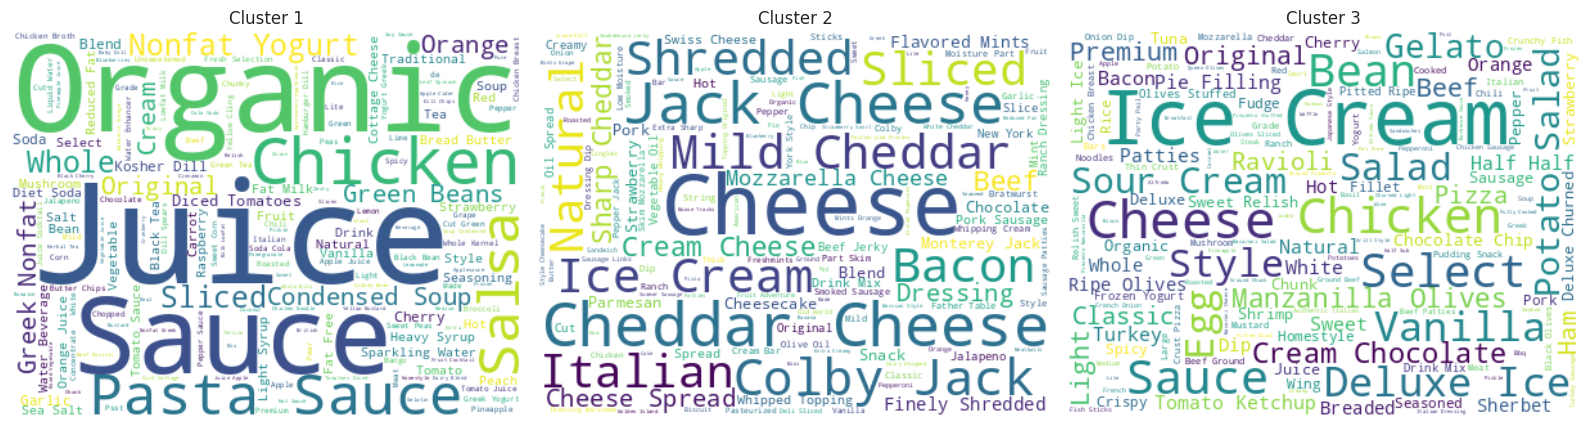

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 16))

axes[0].imshow(wordcloud4, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Cluster 1')

axes[1].imshow(wordcloud5, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Cluster 2')

axes[2].imshow(wordcloud6, interpolation='bilinear')
axes[2].axis('off')
axes[2].set_title('Cluster 3')

plt.tight_layout()
plt.show()

In [19]:
from sklearn.metrics import silhouette_score
silhouette_score = silhouette_score(ketoc, labels2)
print("Silhouette Score:", silhouette_score)

Silhouette Score: 0.6262558484085943


In [21]:
import joblib

# Simpan scaler, PCA, dan model KMeans
joblib.dump(scaler, 'scaler1.pkl')
joblib.dump(kmeans, 'kmeans1.pkl')


['kmeans1.pkl']